# Gradient Descent for Least Squares (the Power-Line Problem)

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture
*"Optimization using Gradient Descent — Least squares"* (Week 2 — Gradients and Gradient
Descent).

This short lecture revisits the **power-line / linear-regression** problem we solved
**analytically** earlier, and solves the *exact same problem* with **gradient descent** —
showing how fast and easy it is.

This notebook:

- recaps the cost function $E(m,b) = 14m^2 + 3b^2 + 38 + 12mb - 42m - 20b$
- recalls the analytical answer $m = \tfrac12,\; b = \tfrac73$, $E = 4.167$
- minimizes $E$ with gradient descent and confirms it lands on the same point
- visualizes the descent path on the cost surface

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Optimization Using Gradients — Analytical Method* and *Gradient Descent in Two
Variables*.

## 1. Introduction

> *"You solved a linear regression problem using power lines. Even with two variables and a
> simple problem, this turned out to be pretty cumbersome. I'm going to show you how to
> solve the exact same problem using gradient descent — and how fast and easy it is."*

Earlier we minimized the power-line cost **analytically**: take the partial derivatives,
set them to zero, and solve the system. That worked, but solving the system is awkward and
gets much worse with more variables. **Gradient descent** sidesteps it by iterating.

## 2. Recap: the cost function and the analytical answer

The three power lines were at $(1,2),(2,5),(3,3)$, and the fiber line $y = mx + b$ has cost

$$
E(m,b) = (m+b-2)^2 + (2m+b-5)^2 + (3m+b-3)^2 = 14m^2 + 3b^2 + 38 + 12mb - 42m - 20b .
$$

> *"Analytically, you found that it was one half and seven thirds, and it gave a value of
> 4.167."*

$$
m^\star = \tfrac12,\qquad b^\star = \tfrac73,\qquad E(m^\star, b^\star) = 4.167 .
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def E(m, b):
    return 14*m**2 + 3*b**2 + 38 + 12*m*b - 42*m - 20*b

print("Analytical optimum: m=1/2, b=7/3")
print("E(1/2, 7/3) =", round(E(0.5, 7/3), 3))

Analytical optimum: m=1/2, b=7/3
E(1/2, 7/3) = 4.167


## 3. The gradient and the descent step

> *"The idea is to minimize the sum-of-squares cost, and this was the gradient. Start at
> some initial point and take tiny steps descending until you find the minimum."*

The gradient of $E$ (computed in the analytical lecture) is

$$
\nabla E = \begin{bmatrix} \partial E/\partial m \\ \partial E/\partial b \end{bmatrix}
         = \begin{bmatrix} 28m + 12b - 42 \\ 12m + 6b - 20 \end{bmatrix}.
$$

The gradient-descent iteration is

$$
\begin{bmatrix} m_{k+1} \\ b_{k+1} \end{bmatrix}
=
\begin{bmatrix} m_k \\ b_k \end{bmatrix}
- \alpha\,\nabla E(m_k, b_k).
$$

In [2]:
def grad_E(m, b):
    return np.array([28*m + 12*b - 42, 12*m + 6*b - 20])

## 4. Running gradient descent

In [3]:
def gradient_descent(grad, start=(0.0, 0.0), alpha=0.02, n_iter=5000, tol=1e-9):
    p = np.array(start, dtype=float)
    history = [p.copy()]
    for _ in range(n_iter):
        step = alpha * grad(*p)
        p = p - step
        history.append(p.copy())
        if np.linalg.norm(step) < tol:
            break
    return p, np.array(history)

(m_fit, b_fit), hist = gradient_descent(grad_E, start=(0.0, 0.0), alpha=0.02)
print(f"gradient descent : m = {m_fit:.5f}, b = {b_fit:.5f}, E = {E(m_fit, b_fit):.5f}")
print(f"analytical answer: m = {0.5:.5f}, b = {7/3:.5f}, E = {E(0.5, 7/3):.5f}")
print(f"iterations: {len(hist) - 1}")

gradient descent : m = 0.50000, b = 2.33333, E = 4.16667
analytical answer: m = 0.50000, b = 2.33333, E = 4.16667
iterations: 1182


## 5. Visualizing the descent

Left: the iterates sliding down the cost surface $E(m,b)$ to the minimum.
Right: the cost decreasing with each iteration.

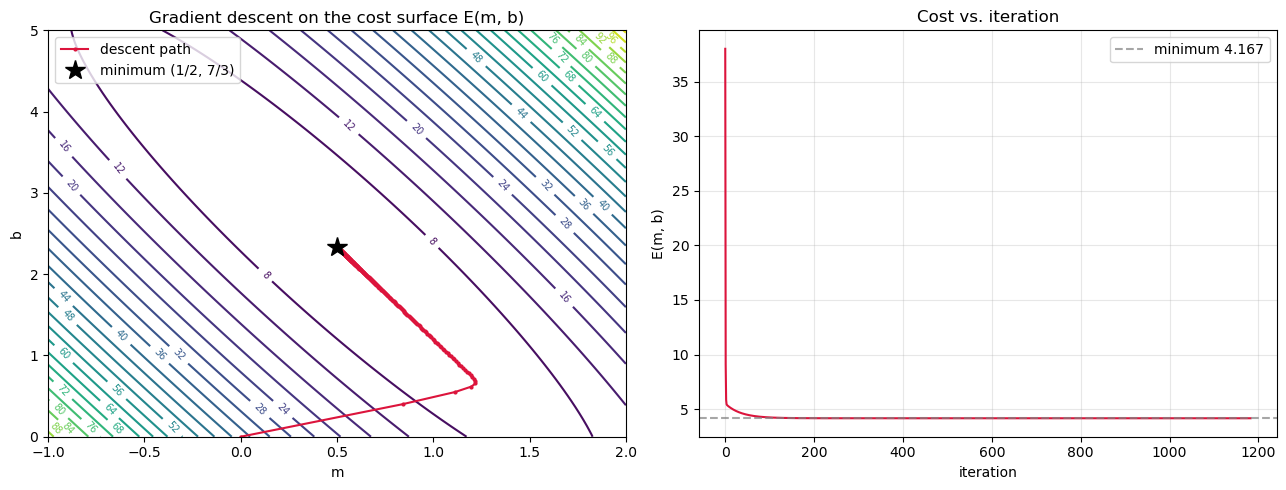

In [4]:
mm = np.linspace(-1, 2, 150)
bb = np.linspace(0, 5, 150)
MM, BB = np.meshgrid(mm, bb)
ZZ = E(MM, BB)

fig = plt.figure(figsize=(13, 5))

ax = fig.add_subplot(1, 2, 1)
cs = ax.contour(MM, BB, ZZ, levels=25, cmap="viridis")
ax.clabel(cs, inline=True, fontsize=7)
ax.plot(hist[:, 0], hist[:, 1], "o-", color="crimson", markersize=2, label="descent path")
ax.plot(0.5, 7/3, "k*", markersize=15, label="minimum (1/2, 7/3)")
ax.set_title("Gradient descent on the cost surface E(m, b)")
ax.set_xlabel("m"); ax.set_ylabel("b"); ax.legend()

ax2 = fig.add_subplot(1, 2, 2)
costs = [E(m, b) for (m, b) in hist]
ax2.plot(costs, color="crimson")
ax2.axhline(E(0.5, 7/3), color="gray", linestyle="--", alpha=0.7, label="minimum 4.167")
ax2.set_title("Cost vs. iteration")
ax2.set_xlabel("iteration"); ax2.set_ylabel("E(m, b)")
ax2.grid(True, alpha=0.3); ax2.legend()

plt.tight_layout()
plt.show()

## 6. Analytical vs. gradient descent

| | Analytical | Gradient descent |
|---|---|---|
| how | solve $\nabla E = 0$ exactly | iterate $\mathbf{p}_{k+1} = \mathbf{p}_k - \alpha\nabla E$ |
| result | exact $(\tfrac12, \tfrac73)$ | converges to $(\tfrac12, \tfrac73)$ |
| scaling | system gets hard with more variables | stays simple — just evaluate the gradient |

Both reach the same answer; gradient descent scales gracefully to many parameters, which is
why it is the method of choice in machine learning.

## 7. Exercises

### Basic
1. Write the gradient $\nabla E$ for $E(m,b) = 14m^2 + 3b^2 + 38 + 12mb - 42m - 20b$.
2. What is the gradient-descent update rule for $(m, b)$?

### Intermediate
3. Run gradient descent from a different start, e.g. $(2, 0)$. Does it still reach
   $(\tfrac12, \tfrac73)$?
4. Try a larger learning rate (e.g. $\alpha = 0.06$). What happens, and why?

### Advanced
5. Compute the eigenvalues of the Hessian $\begin{bmatrix} 28 & 12 \\ 12 & 6 \end{bmatrix}$
   and use them to explain why this problem needs a fairly small learning rate.
6. Explain one advantage of gradient descent over the analytical method when the number of
   parameters is large.

## 8. Solutions / Checks

In [5]:
# 3. different start
(m3, b3), h3 = gradient_descent(grad_E, start=(2.0, 0.0), alpha=0.02)
print(f"3. from (2,0) -> m={m3:.4f}, b={b3:.4f} ({len(h3)-1} iters)")

# 4. larger learning rate
(m4, b4), h4 = gradient_descent(grad_E, start=(0.0, 0.0), alpha=0.06, n_iter=200)
status = "diverged" if not np.isfinite(E(m4, b4)) or E(m4, b4) > 1e6 else f"E={E(m4,b4):.3f}"
print(f"4. α=0.06 -> {status} (too large: overshoots)")

# 5. Hessian eigenvalues
H = np.array([[28, 12], [12, 6]])
eig = np.linalg.eigvalsh(H)
print(f"5. Hessian eigenvalues = {np.round(eig, 3)}; "
      f"stability needs α < 2/λmax = {2/eig.max():.3f}, and the small λmin makes one "
      "direction converge slowly (ill-conditioned).")

print("6. Gradient descent only evaluates the gradient each step, so it scales to many "
      "parameters without solving a large system of equations.")

3. from (2,0) -> m=0.5000, b=2.3333 (1205 iters)
4. α=0.06 -> E=12.928 (too large: overshoots)
5. Hessian eigenvalues = [ 0.721 33.279]; stability needs α < 2/λmax = 0.060, and the small λmin makes one direction converge slowly (ill-conditioned).
6. Gradient descent only evaluates the gradient each step, so it scales to many parameters without solving a large system of equations.


## 9. Conclusion

- The power-line / linear-regression problem can be solved **either** analytically (solve
  $\nabla E = 0$) **or** by **gradient descent** (iterate $\mathbf{p}_{k+1} = \mathbf{p}_k
  - \alpha\nabla E$).
- Both reach the same optimum $m = \tfrac12,\; b = \tfrac73$ with $E = 4.167$.
- Gradient descent is just as accurate here and **scales** to many variables, where the
  analytical system becomes cumbersome — which is why it dominates machine learning.
- Next: the same idea with **many observations** (the full least-squares regression).

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/gradien_des_1.mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 2) lecture *"Optimization using Gradient Descent — Least squares"*. Key
spoken points, lightly cleaned:

> You solved a linear regression problem with power lines, but even this simple
> two-variable problem was cumbersome. Here's the same problem solved with gradient
> descent — fast and easy. The power-line example minimized $E(m,b)$; analytically the
> optimum was $m=1/2$, $b=7/3$, giving $4.167$. We can also do it with gradient descent:
> minimize the sum-of-squares cost using its gradient. Start at some random $(m_0, b_0)$
> and iterate $(m_{k+1}, b_{k+1}) = (m_k, b_k) - \alpha\,\nabla E(m_k, b_k)$, taking tiny
> descending steps until you reach the minimum.